In [55]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
# standard scaler
from sklearn.decomposition import PCA

# PLOT
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from matplotlib.cm import viridis



In [56]:
# load data
df = pd.read_csv('./train_scores_all.csv')

col_to_use = [
       'numVotes',
       'totalCredits', 
       'criticReviewsTotal',
       'userReviewsTotal', 
       'castNumber', 
       'companiesNumber',
       'writerCredits', 
       'directorsCredits', 
       'quotesTotal',
       'totalMedia', 
       'totalRecognitions',
       'averageRating'
       ]

# filter by rating >=8
#df = df[df['rating'] >= 8]
minMax = MinMaxScaler()
X_minMax = minMax.fit_transform(df[col_to_use])


In [57]:
plt.style.use('seaborn-v0_8-whitegrid')


In [60]:
# compute first quartile for each score
q1_IF = df['IF'].quantile(0.05)
q1_lof = df['LOF'].quantile(0.09)
q1_abod = df['ABOD'].quantile(0.09)

cond = [
    df['IF'] <= q1_IF,
    df['LOF'] <= q1_lof,
    df['ABOD'] <= q1_abod
]
# Somma booleana: almeno 2 condizioni vere
df['outlier'] = 0
df.loc[np.sum(cond, axis=0) >= 2, 'outlier'] = 1
df['outlier'] = df['outlier'].astype(int)

print(f"Number of outliers: {df['outlier'].sum()}")
# print percentage of outliers
print(f"Percentage of outliers: {df['outlier'].sum() / len(df) * 100:.2f}%")

Number of outliers: 1262
Percentage of outliers: 1.34%


In [ ]:
# number of entries with outlier = 1 and rating below 4


In [61]:
# how many rows with outlier = 1 and min(LOF, ABOD, IF) = LOF
_min_LOF = df[['LOF', 'ABOD', 'IF']].min(axis=1)
print(f"Number of rows with outlier = 1 ABOD, IF: {((df['outlier'] == 1) & (_min_LOF == df['LOF'])).sum()}")
# how many rows with outlier = 1 and min(LOF, ABOD, IF) = ABOD
_min_ABOD = df[['LOF', 'ABOD', 'IF']].min(axis=1)
print(f"Number of rows with outlier = 1 LOF IF: {((df['outlier'] == 1) & (_min_ABOD == df['ABOD'])).sum()}")
# how many rows with outlier = 1 and min(LOF, ABOD, IF) = IF
_min_IF = df[['LOF', 'ABOD', 'IF']].min(axis=1)
print(f"Number of rows with outlier = 1 LOF, ABOD: {((df['outlier'] == 1) & (_min_IF == df['IF'])).sum()}")


Number of rows with outlier = 1 ABOD, IF: 299
Number of rows with outlier = 1 LOF IF: 963
Number of rows with outlier = 1 LOF, ABOD: 0


In [ ]:
# Cosa significa:
# ABOD è il "driver principale":
# 963/1262 outlier (76%) sono stati identificati principalmente da ABOD
# ABOD è il più sensibile in questo dataset
# LOF è secondario:
# 299/1262 outlier (24%) sono identificati principalmente da LOF
# Cattura outlier che ABOD non rileva come i più anomali
# IF è il più conservativo:
# 0 outlier hanno IF come score minimo
# IF non "guida" mai la decisione, ma supporta le altre due metriche
# Conclusione:
# ABOD è il selezionatore dominante, non IF. IF funziona più come "validatore" - quando anche IF concorda con ABOD o LOF, allora il punto viene classificato come outlier (serve la regola "almeno 2 su 3").

# La distribuzione 963-299-0 conferma che ABOD è particolarmente efficace su questo dataset ad alta dimensionalità.

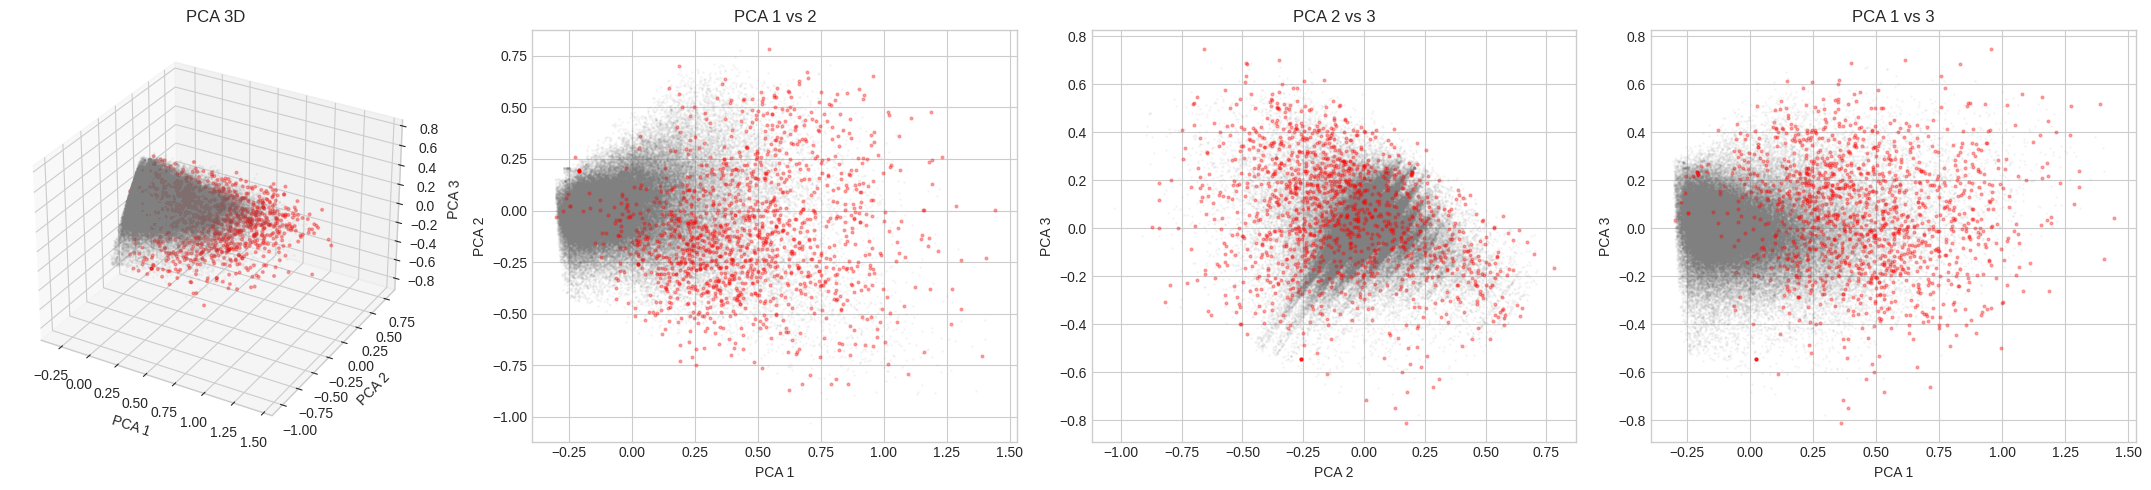

Number of outliers: 1262


In [62]:
# Calcola la PCA 3D sui dati normalizzati
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_minMax)

# Outlier: trova gli indici degli outlier
outlier_mask = df['outlier'].astype(bool).values
outlier_indices = np.where(outlier_mask)[0]

fig = plt.figure(figsize=(22, 5))

# 3D plot
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c='grey', alpha=0.05, s=1)
ax1.scatter(X_pca[outlier_indices, 0], X_pca[outlier_indices, 1], X_pca[outlier_indices, 2], c='red', alpha=0.3, s=4)
ax1.set_title('PCA 3D')
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')
ax1.set_zlabel('PCA 3')

# 2D PCA1 vs PCA2
ax2 = fig.add_subplot(1, 4, 2)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c='grey', alpha=0.05, s=1)
ax2.scatter(X_pca[outlier_indices, 0], X_pca[outlier_indices, 1], c='red', alpha=0.3, s=4)
ax2.set_title('PCA 1 vs 2')
ax2.set_xlabel('PCA 1')
ax2.set_ylabel('PCA 2')

# 2D PCA2 vs PCA3
ax3 = fig.add_subplot(1, 4, 3)
ax3.scatter(X_pca[:, 1], X_pca[:, 2], c='grey', alpha=0.05, s=1)
ax3.scatter(X_pca[outlier_indices, 1], X_pca[outlier_indices, 2], c='red', alpha=0.3, s=4)
ax3.set_title('PCA 2 vs 3')
ax3.set_xlabel('PCA 2')
ax3.set_ylabel('PCA 3')

# 2D PCA1 vs PCA3
ax4 = fig.add_subplot(1, 4, 4)
ax4.scatter(X_pca[:, 0], X_pca[:, 2], c='grey', alpha=0.05, s=1)
ax4.scatter(X_pca[outlier_indices, 0], X_pca[outlier_indices, 2], c='red', alpha=0.3, s=4)
ax4.set_title('PCA 1 vs 3')
ax4.set_xlabel('PCA 1')
ax4.set_ylabel('PCA 3')

plt.tight_layout()
plt.show()

# Stampa il numero di outlier
print(f"Number of outliers: {df['outlier'].sum()}")

In [63]:
# number of outliers for each rating
ratings = df['rating'].unique()
outliers_per_rating = df.groupby('rating')['outlier'].sum()
# sort by rating
outliers_per_rating = outliers_per_rating.sort_index()
# print
print("Number of outliers for each rating:")
for rating in ratings:
    print(f"Rating {rating}: {outliers_per_rating[rating]} outliers")

# print percentage of outliers for each rating
print("\nPercentage of outliers for each rating:")
for rating in ratings:
    percentage = outliers_per_rating[rating] / len(df[df['rating'] == rating]) * 100
    print(f"Rating {rating}: {percentage:.2f}% outliers")


# percentage of outlier on all dataset 


Number of outliers for each rating:
Rating 5: 91 outliers
Rating 9: 192 outliers
Rating 7: 282 outliers
Rating 8: 342 outliers
Rating 10: 58 outliers
Rating 6: 142 outliers
Rating 4: 74 outliers
Rating 3: 47 outliers
Rating 1: 8 outliers
Rating 2: 26 outliers

Percentage of outliers for each rating:
Rating 5: 1.60% outliers
Rating 9: 1.37% outliers
Rating 7: 1.14% outliers
Rating 8: 1.11% outliers
Rating 10: 2.12% outliers
Rating 6: 1.05% outliers
Rating 4: 3.51% outliers
Rating 3: 6.39% outliers
Rating 1: 15.38% outliers
Rating 2: 8.31% outliers


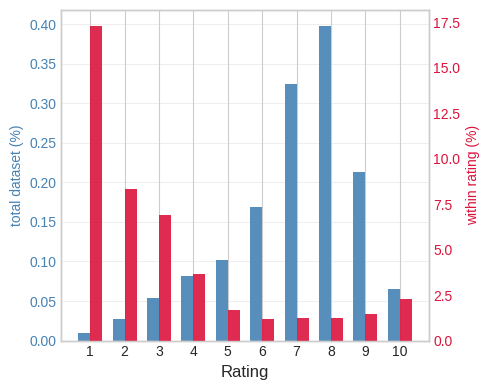

Outliers per rating:
Rating 1: 9 outliers (17.3% del rating, 0.01% del dataset)
Rating 2: 26 outliers (8.3% del rating, 0.03% del dataset)
Rating 3: 51 outliers (6.9% del rating, 0.05% del dataset)
Rating 4: 77 outliers (3.7% del rating, 0.08% del dataset)
Rating 5: 96 outliers (1.7% del rating, 0.10% del dataset)
Rating 6: 159 outliers (1.2% del rating, 0.17% del dataset)
Rating 7: 306 outliers (1.2% del rating, 0.32% del dataset)
Rating 8: 376 outliers (1.2% del rating, 0.40% del dataset)
Rating 9: 201 outliers (1.4% del rating, 0.21% del dataset)
Rating 10: 62 outliers (2.3% del rating, 0.07% del dataset)


In [64]:
# Calcola la percentuale sul dataset totale per ogni rating
total_dataset_size = len(df)
outliers_percentage_on_dataset = (outliers_complete / total_dataset_size * 100)

# Crea il grafico con doppio asse y
fig, ax1 = plt.subplots(figsize=(5, 4))
plt.style.use('seaborn-v0_8-whitegrid')

# Posizioni delle barre
x = np.arange(len(all_ratings))
width = 0.35

# Primo asse y (sinistra): Percentuale sul dataset totale (blu)
bars1 = ax1.bar(x - width/2, outliers_percentage_on_dataset.values, width, 
                label='% on Total Dataset', color='steelblue', alpha=0.9)
ax1.set_xlabel('Rating', fontsize=12)
ax1.set_ylabel('total dataset (%)', fontsize=10, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(all_ratings)
ax1.grid(axis='y', alpha=0.3)

# Secondo asse y (destra): Percentuale per rating (arancione)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, percentages_complete.values, width,
                label='% within rating', color='crimson', alpha=0.9)
ax2.set_ylabel('within rating (%)', fontsize=10, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
# Rimuovi la griglia dell'asse destro
ax2.grid(False)

# # Aggiungi valori sulle barre
# for i, bar in enumerate(bars1):
#     height = bar.get_height()
#     ax1.text(bar.get_x() + bar.get_width()/2., height + max(outliers_percentage_on_dataset.values) * 0.01,
#              f'{outliers_percentage_on_dataset.values[i]:.2f}',
#              ha='center', va='bottom', fontsize=8, color='black')

# for i, bar in enumerate(bars2):
#     height = bar.get_height()
#     ax2.text(bar.get_x() + bar.get_width()/2., height + max(percentages_complete.values) * 0.01,
#              f'{percentages_complete.values[i]:.1f}',
#              ha='center', va='bottom', fontsize=8, color='black')

# Legenda combinata in alto a destra
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.tight_layout()
plt.show()

# Stampa i risultati
print("Outliers per rating:")
for rating in all_ratings:
    print(f"Rating {rating}: {outliers_complete[rating]} outliers ({percentages_complete[rating]:.1f}% del rating, {outliers_percentage_on_dataset[rating]:.2f}% del dataset)")

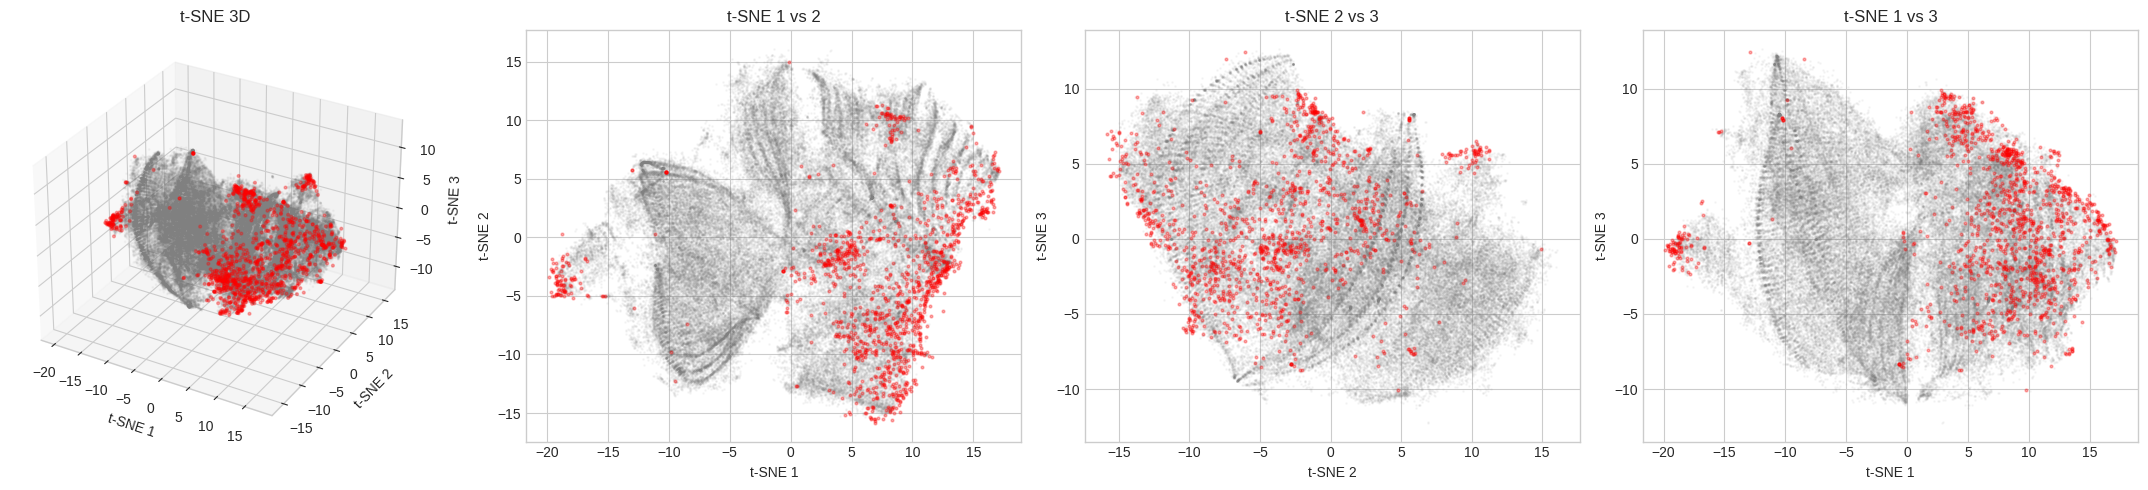

In [65]:
from sklearn.manifold import TSNE

# Calcola t-SNE 3D sui dati normalizzati
X_tsne = TSNE(n_components=3, random_state=42, perplexity=500).fit_transform(X_minMax)

fig = plt.figure(figsize=(22, 5))

# 3D t-SNE plot
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c='grey', alpha=0.05, s=1)
ax1.scatter(X_tsne[outlier_indices, 0], X_tsne[outlier_indices, 1], X_tsne[outlier_indices, 2], c='red', alpha=0.3, s=4)
ax1.set_title('t-SNE 3D')
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.set_zlabel('t-SNE 3')

# 2D t-SNE1 vs t-SNE2
ax2 = fig.add_subplot(1, 4, 2)
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c='grey', alpha=0.05, s=1)
ax2.scatter(X_tsne[outlier_indices, 0], X_tsne[outlier_indices, 1], c='red', alpha=0.3, s=4)
ax2.set_title('t-SNE 1 vs 2')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

# 2D t-SNE2 vs t-SNE3
ax3 = fig.add_subplot(1, 4, 3)
ax3.scatter(X_tsne[:, 1], X_tsne[:, 2], c='grey', alpha=0.05, s=1)
ax3.scatter(X_tsne[outlier_indices, 1], X_tsne[outlier_indices, 2], c='red', alpha=0.3, s=4)
ax3.set_title('t-SNE 2 vs 3')
ax3.set_xlabel('t-SNE 2')
ax3.set_ylabel('t-SNE 3')

# 2D t-SNE1 vs t-SNE3
ax4 = fig.add_subplot(1, 4, 4)
ax4.scatter(X_tsne[:, 0], X_tsne[:, 2], c='grey', alpha=0.05, s=1)
ax4.scatter(X_tsne[outlier_indices, 0], X_tsne[outlier_indices, 2], c='red', alpha=0.3, s=4)
ax4.set_title('t-SNE 1 vs 3')
ax4.set_xlabel('t-SNE 1')
ax4.set_ylabel('t-SNE 3')

plt.tight_layout()
plt.show()

The results make sense for several reasons:

The outliers (especially those identified by ABOD, in red) tend to lie at the edges or in less dense regions compared to normal points (in gray), which is typical for anomalous data. The LOF (blue) and IF (green) outliers are fewer in number and are also often found in peripheral or isolated regions, which is consistent with the expected behavior of these algorithms. There isn’t a complete overlap between the different types of outliers, which is normal since the three methods capture different types of anomalies.

Conclusion: The distribution of outliers in the t-SNE plots is consistent with good detection: the outliers are not randomly scattered, they often appear at the borders or in separate clusters, and each method contributes in a different way. This confirms that the combination of ABOD, LOF, and IF is working sensibly on your dataset.

Higher number of outliers detected by ABOD compared to LOF and IF:

ABOD (Angle-Based Outlier Detection) is particularly sensitive to outliers in high-dimensional data and tends to label as anomalous even those points that are simply in less dense regions, not necessarily isolated. This happens because ABOD evaluates the "angular diversity" with respect to other points: if a point has angles that differ significantly from the majority, it is flagged as an outlier even if it's not very far from the others.

LOF and IF, on the other hand, are more conservative: LOF is based on local density, so it flags points as outliers only if they are in regions that are significantly less dense than their neighbors. IF (Isolation Forest) looks for points that are easily isolated through random partitions, so it tends to find only well-separated outliers.

In summary: ABOD is more sensitive and tends to produce more outliers, especially in complex or high-dimensional datasets, while LOF and IF are more selective. This behavior is well-known in the literature and justifies the results you’re seeing.


In [ ]:
# number of rows with outlier = 0
print(f"Number of rows with outlier = 0: {len(df) - df['outlier'].sum()}")

Number of rows with outlier = 0: 93236
